In [1]:
# Charger le dataset propre

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/final_clean.csv")
df.head()

,year,Rank,Country,Life evaluation (3-year average),country_id,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Gross National Income (USD)
0,2024,147,Afghanistan,1.364,af,-6.601186,6.172933e+10,6022.347976,13.295,3.611046,3.344239,-2.233175,5.882768e+10
1,2023,143,Afghanistan,1.721,af,-4.644709,1.723305e+10,415.707417,13.991,2.961654,2.710887,-2.233175,1.731538e+10
2,2022,137,Afghanistan,1.859,af,13.712102,1.449724e+10,357.261153,14.100,9.406239,-6.240172,-2.233175,1.454030e+10
3,2021,146,Afghanistan,2.404,af,5.133203,1.426000e+10,356.496214,11.994,2.838996,-20.738839,-2.233175,1.434609e+10
4,2020,150,Afghanistan,2.523,af,5.601888,1.995593e+10,510.787063,11.710,6.962946,-2.351101,-15.718303,2.010516e+10


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1923 entries, 0 to 1922
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   year                              1923 non-null   int64  
 1   Rank                              1923 non-null   int64  
 2   Country                           1923 non-null   object 
 3   Life evaluation (3-year average)  1923 non-null   float64
 4   country_id                        1923 non-null   object 
 5   Inflation (CPI %)                 1923 non-null   float64
 6   GDP (Current USD)                 1923 non-null   float64
 7   GDP per Capita (Current USD)      1923 non-null   float64
 8   Unemployment Rate (%)             1923 non-null   float64
 9   Inflation (GDP Deflator, %)       1923 non-null   float64
 10  GDP Growth (% Annual)             1923 non-null   float64
 11  Current Account Balance (% GDP)   1923 non-null   float64
 12  Gross 

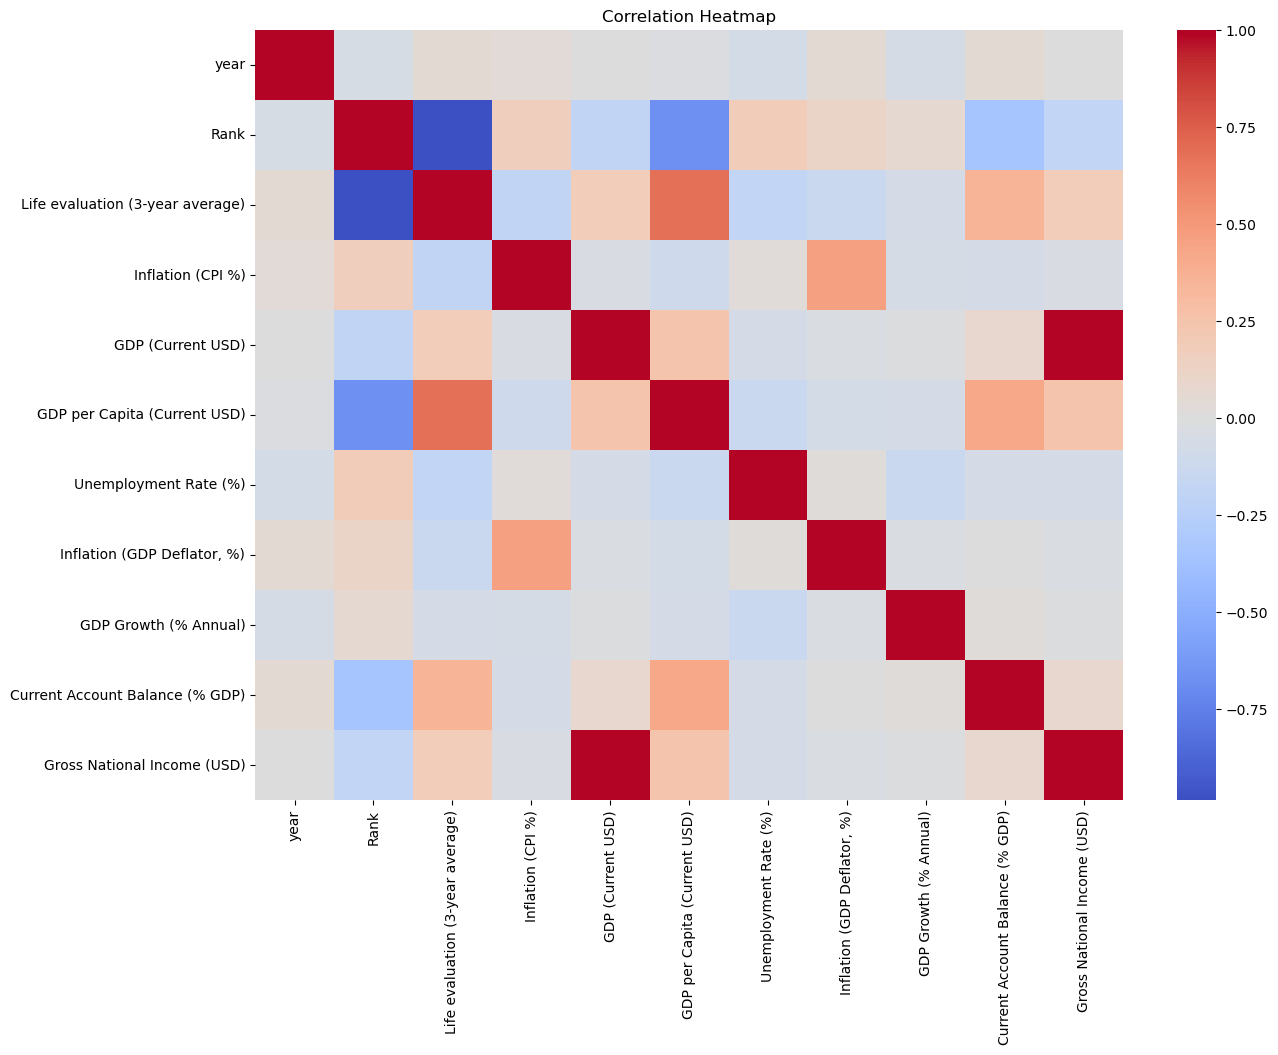

In [6]:
# heatmap de corrélation :

numeric_df = df.select_dtypes(include=["float64", "int64"])

plt.figure(figsize=(14,10))
sns.heatmap(numeric_df.corr(), annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


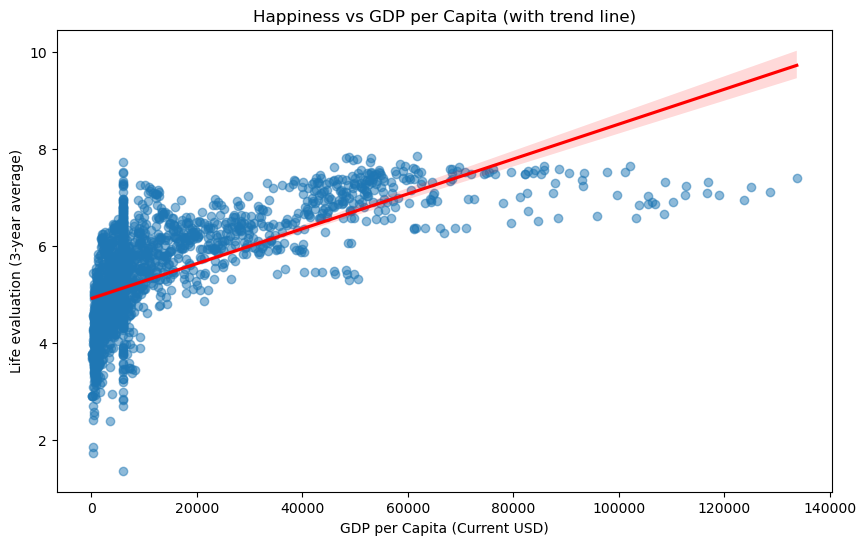

In [7]:
# Happiness vs GDP per Capita

plt.figure(figsize=(10,6))
sns.regplot(
    data=df,
    x="GDP per Capita (Current USD)",
    y="Life evaluation (3-year average)",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)
plt.title("Happiness vs GDP per Capita (with trend line)")
plt.show()

Ce graphique met en évidence une relation claire entre le PIB par habitant et le niveau de bonheur.

Les pays les plus riches présentent systématiquement des niveaux de satisfaction de vie plus élevés.

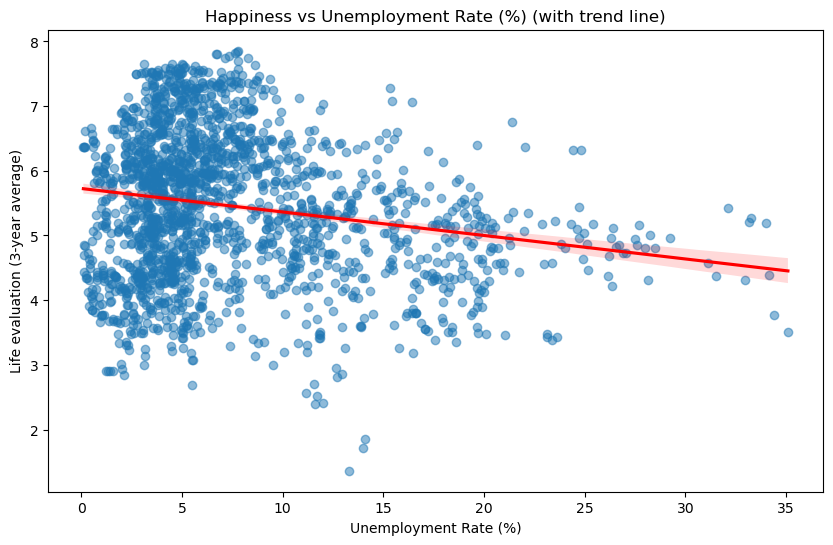

In [9]:
# Happiness vs Unemployment Rate (%)

plt.figure(figsize=(10,6))
sns.regplot(
    data=df,
    x="Unemployment Rate (%)",
    y="Life evaluation (3-year average)",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)
plt.title("Happiness vs Unemployment Rate (%) (with trend line)")
plt.show()

Ce graphique suggère une relation négative entre le taux de chômage et le niveau de bonheur, mais celle‑ci reste modérée et peu structurée.
La dispersion importante des points montre que des pays ayant un chômage similaire peuvent présenter des niveaux de bien‑être très différents.
La tendance descendante n’apparaît réellement qu’au‑delà d’un certain seuil de chômage, où l’impact économique devient plus marqué.

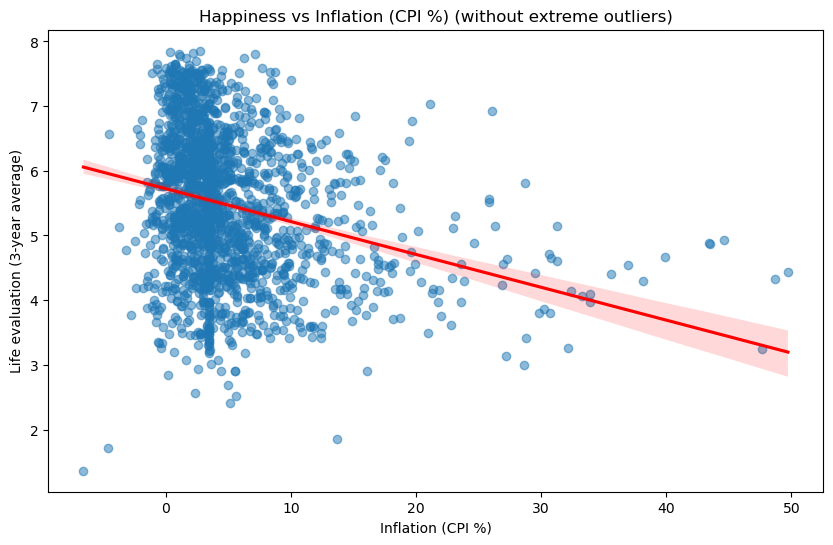

In [12]:
# Happiness vs Inflation

df_no_outliers = df[df["Inflation (CPI %)"] < 50]

plt.figure(figsize=(10,6))
sns.regplot(
    data=df_no_outliers,
    x="Inflation (CPI %)",
    y="Life evaluation (3-year average)",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)
plt.title("Happiness vs Inflation (CPI %) (without extreme outliers)")
plt.show()

L’inflation n’a pas de relation claire avec le bonheur pour la majorité des pays, car la plupart se situent dans une zone d’inflation modérée (0–10 %) où les niveaux de bonheur sont très dispersés. Ce n’est que dans les cas d’inflation extrême que l’on observe une baisse nette du bonheur.

Les extrêmes (hyperinflation ou déflation) sont associés à un faible bonheur, mais dans la zone normale (0–10 %), l’inflation n’explique presque rien.

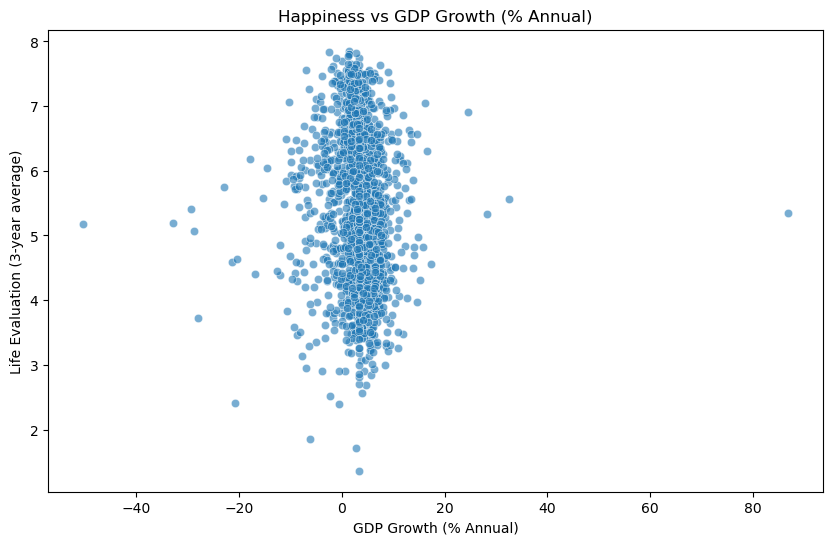

In [14]:
# Happiness vs GDP Growth (% Annual)

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="GDP Growth (% Annual)",
    y="Life evaluation (3-year average)",
    alpha=0.6
)
plt.title("Happiness vs GDP Growth (% Annual)")
plt.xlabel("GDP Growth (% Annual)")
plt.ylabel("Life Evaluation (3-year average)")
plt.show()

La croissance annuelle du PIB n’a pas de relation claire avec le bonheur. Les pays peuvent connaître une forte croissance tout en ayant un bonheur modéré, ou une faible croissance tout en étant très heureux. Le bonheur dépend davantage de facteurs structurels que de variations économiques de court terme

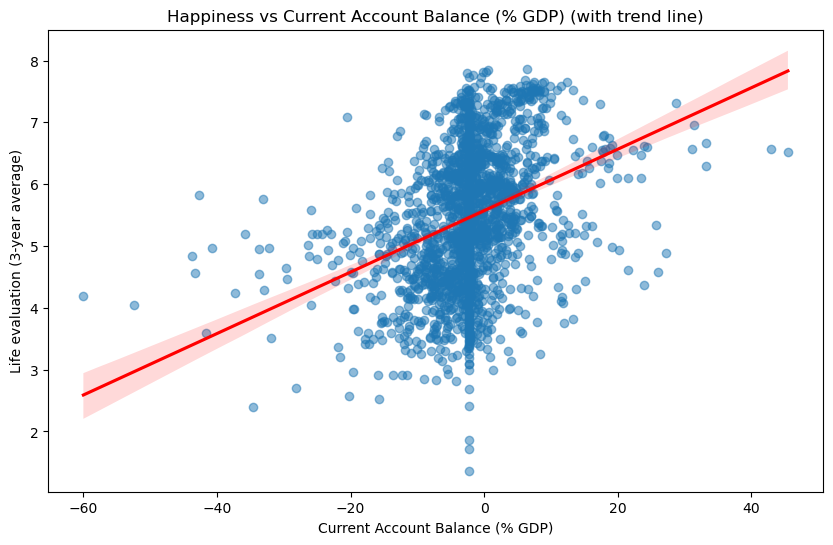

In [15]:
# Happiness vs Current Account Balance (% GDP)

plt.figure(figsize=(10,6))
sns.regplot(
    data=df,
    x="Current Account Balance (% GDP)",
    y="Life evaluation (3-year average)",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)
plt.title("Happiness vs Current Account Balance (% GDP) (with trend line)")
plt.show()